In [1]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [18]:
# Check null values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

In [3]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())

In [4]:
def risk_category(row):
    if row['loan_status'] == 1:
        return "High Risk"
    elif row['loan_percent_income'] > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_category'] = df.apply(risk_category, axis=1)

In [5]:
df['DTI'] = df['loan_amnt'] / df['person_income']

In [6]:
df['default_flag'] = df['loan_status']

In [7]:
# Default rate
default_rate = df['loan_status'].mean()
print("Default Rate:", default_rate)

# Group by risk
df.groupby('risk_category')['loan_status'].mean()

# Income vs loan
df[['person_income','loan_amnt']].describe()

Default Rate: 0.21868830207305034


,person_income,loan_amnt
count,3.241600e+04,32416.000000
mean,6.609164e+04,9593.845632
std,6.201558e+04,6322.730241
min,4.000000e+03,500.000000
25%,3.854200e+04,5000.000000
50%,5.500000e+04,8000.000000
75%,7.921800e+04,12250.000000
max,6.000000e+06,35000.000000


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sns.set(style="whitegrid")

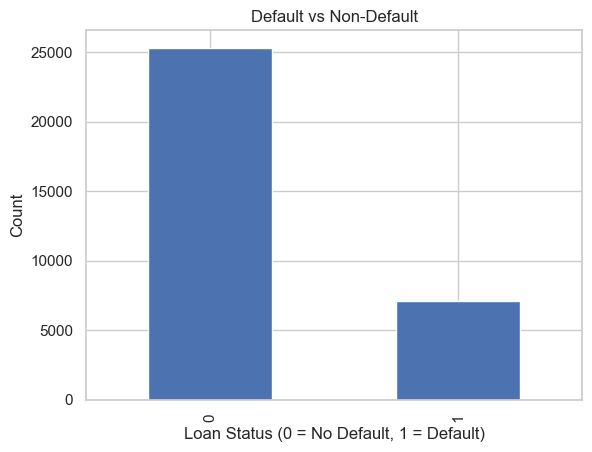

In [10]:
plt.figure()
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Default vs Non-Default")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.show()

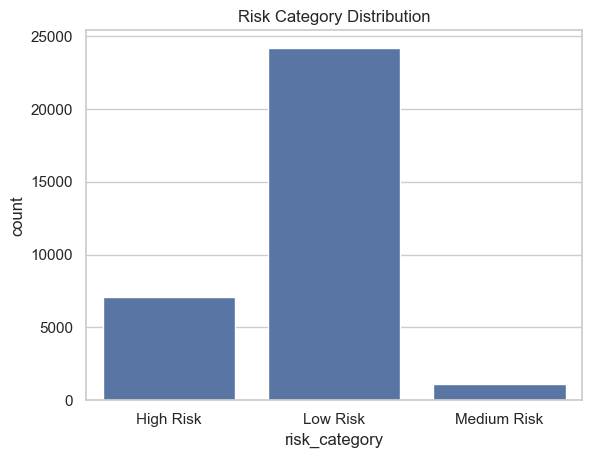

In [11]:
plt.figure()
sns.countplot(x='risk_category', data=df)
plt.title("Risk Category Distribution")
plt.show()

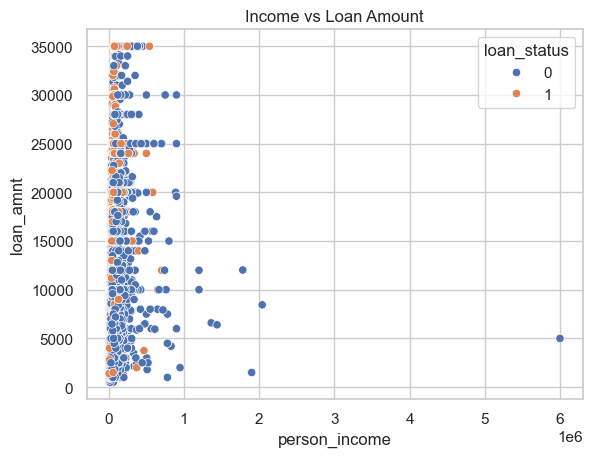

In [12]:
plt.figure()
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

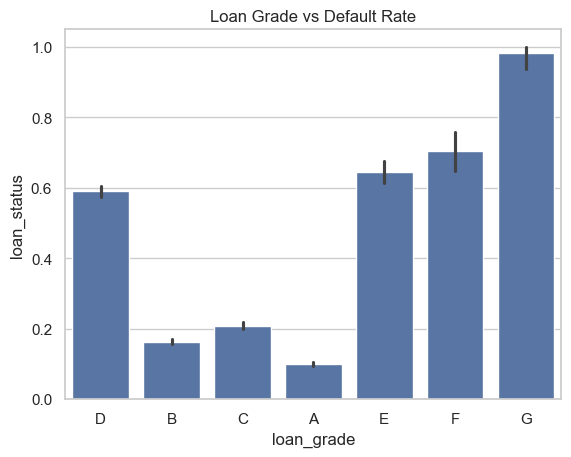

In [13]:
plt.figure()
sns.barplot(x='loan_grade', y='loan_status', data=df)
plt.title("Loan Grade vs Default Rate")
plt.show()

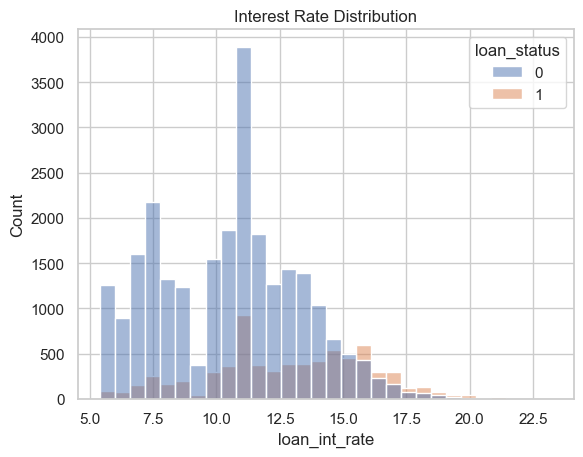

In [14]:
plt.figure()
sns.histplot(data=df, x='loan_int_rate', hue='loan_status', bins=30)
plt.title("Interest Rate Distribution")
plt.show()

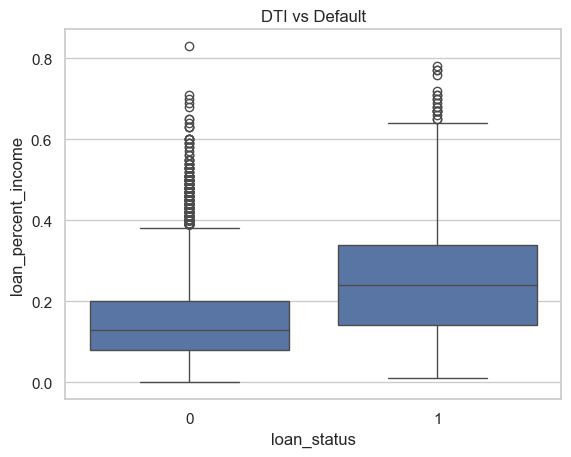

In [15]:
plt.figure()
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title("DTI vs Default")
plt.show()

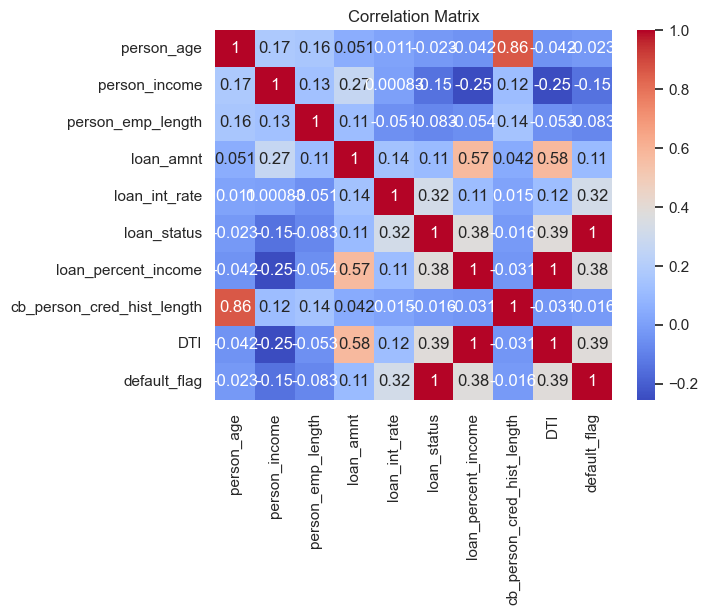

In [16]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:
plt.savefig("graph_name.png")

<Figure size 640x480 with 0 Axes>